In [18]:
import os
import tensorflow as tf
import kagglehub

# Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

dataset_path = os.path.join(path, "chest_xray")
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

print("Train folders:", os.listdir(train_path))

Train folders: ['NORMAL', 'PNEUMONIA']


In [19]:
IMG_SIZE = (192, 192)
BATCH_SIZE = 16

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


In [20]:
preprocess = tf.keras.applications.efficientnet.preprocess_input

train_data = train_data.map(lambda x, y: (preprocess(x), y))
val_data = val_data.map(lambda x, y: (preprocess(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)

In [21]:
normal_count = len(os.listdir(os.path.join(train_path, "NORMAL")))
pneumonia_count = len(os.listdir(os.path.join(train_path, "PNEUMONIA")))

total = normal_count + pneumonia_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}

print("Class weight:", class_weight)

Class weight: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [22]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(192,192,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 173s 482ms/step - accuracy: 0.7281 - auc: 0.8262 - loss: 0.5543 - precision: 0.8995 - recall: 0.7138 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.4340 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 200s 474ms/step - accuracy: 0.8443 - auc: 0.9322 - loss: 0.3978 - precision: 0.9535 - recall: 0.8310 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.3349 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 201s 470ms/step - accuracy: 0.8631 - auc: 0.9500 - loss: 0.3326 - precision: 0.9642 - recall: 0.8472 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2817 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 199s 460ms/step - accuracy: 0.8781 - auc: 0.9578 - loss: 0.2975 - precision: 0.9706 - recall: 0.8619 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2481 - val_precision: 0.8750 - val_recall: 0.8750
Epoch 5/15
326/3

# Fine-Tune EfficientNet

In [26]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with Lower Learning Rate

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Train Again (Fine-Tuning Phase)

In [28]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weight
)

Epoch 1/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 199s 548ms/step - accuracy: 0.8742 - auc: 0.9702 - loss: 0.2613 - precision: 0.9867 - recall: 0.8421 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.2423 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 2/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 169s 516ms/step - accuracy: 0.9109 - auc: 0.9792 - loss: 0.2076 - precision: 0.9871 - recall: 0.8916 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2093 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 3/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 200s 511ms/step - accuracy: 0.9237 - auc: 0.9829 - loss: 0.1820 - precision: 0.9849 - recall: 0.9112 - val_accuracy: 0.9375 - val_auc: 0.9922 - val_loss: 0.1863 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 4/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 201s 507ms/step - accuracy: 0.9340 - auc: 0.9870 - loss: 0.1592 - precision: 0.9865 - recall: 0.9239 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1748 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 5/8
326/326 ━━

# Evaluate with Custom Threshold

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = []
y_pred_prob = []

for images, labels in val_data:
    preds = model.predict(images)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Change threshold here
threshold = 0.4
y_pred = (y_pred_prob > threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Confusion Matrix:
 [[8 0]
 [1 7]]


In [ ]:
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# K-Fold Cross Validation

In [30]:
validation_split=0.2
subset="training"
subset="validation"

# Combine Train + Val Folders

In [31]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold

# Load All Image Paths Manually

In [32]:
all_images = []
all_labels = []

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

for img in os.listdir(normal_path):
    all_images.append(os.path.join(normal_path, img))
    all_labels.append(0)

for img in os.listdir(pneumonia_path):
    all_images.append(os.path.join(pneumonia_path, img))
    all_labels.append(1)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print("Total images:", len(all_images))

Total images: 5216


# Define Image Loader Function

In [33]:
IMG_SIZE = (192, 192)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# K-Fold Setup

In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
val_accuracies = []
val_aucs = []

# Training Loop

In [35]:
for train_index, val_index in kf.split(all_images):

    print(f"\n🔥 Fold {fold_no}")

    train_images, val_images = all_images[train_index], all_images[val_index]
    train_labels, val_labels = all_labels[train_index], all_labels[val_index]

    train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))

    train_ds = train_ds.map(load_image).batch(16).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(load_image).batch(16).prefetch(tf.data.AUTOTUNE)

    # Build fresh model each fold
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(192,192,3)
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name="auc")]
    )

    history = model.fit(train_ds,
                        validation_data=val_ds,
                        epochs=5,
                        verbose=1)

    val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=0)

    val_accuracies.append(val_acc)
    val_aucs.append(val_auc)

    fold_no += 1


🔥 Fold 1
Epoch 1/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 182s 637ms/step - accuracy: 0.7383 - auc: 0.7953 - loss: 0.5037 - val_accuracy: 0.7251 - val_auc: 0.8379 - val_loss: 0.5949
Epoch 2/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 149s 572ms/step - accuracy: 0.7546 - auc: 0.7234 - loss: 0.5049 - val_accuracy: 0.7251 - val_auc: 0.9350 - val_loss: 0.5157
Epoch 3/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 211s 606ms/step - accuracy: 0.7929 - auc: 0.8146 - loss: 0.4384 - val_accuracy: 0.7299 - val_auc: 0.9530 - val_loss: 0.4456
Epoch 4/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 161s 617ms/step - accuracy: 0.8245 - auc: 0.8718 - loss: 0.3867 - val_accuracy: 0.7529 - val_auc: 0.9595 - val_loss: 0.3941
Epoch 5/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 197s 599ms/step - accuracy: 0.8418 - auc: 0.8994 - loss: 0.3527 - val_accuracy: 0.7768 - val_auc: 0.9638 - val_loss: 0.3581

🔥 Fold 2
Epoch 1/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 164s 564ms/step - accuracy: 0.7503 - auc: 0.8217 - loss: 0.4776 - val_accuracy: 0.7421 - val_auc: 0.8535 - val_loss: 0.5517
Ep

In [36]:
print("\n📊 Cross-Validation Results")
print("Mean Accuracy:", np.mean(val_accuracies))
print("Std Accuracy:", np.std(val_accuracies))
print("Mean AUC:", np.mean(val_aucs))
print("Std AUC:", np.std(val_aucs))


📊 Cross-Validation Results
Mean Accuracy: 0.797358238697052
Std Accuracy: 0.011421861434666072
Mean AUC: 0.9618125200271607
Std AUC: 0.002494409264677165


# X-AI

In [37]:
!pip install opencv-python matplotlib

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 426.6 kB/s eta 0:01:34
    --------------------------------------- 0.5/40.2 MB 426.6 kB/s eta 0:01:34
    --------------------------------------- 0.5/40.2 MB 426.6 kB/s eta 0:01:34
    --------------------------------------- 0.8/40.2 MB 445.4 kB/s eta 0:01:29
    --------------------------------------- 0.8/40.2 MB 445.4 kB/s eta 0:01:29
   - -------------------------------------- 1.0/40.2 MB 474.4 kB/s eta 0:01:23
   - -------------------------------

In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

In [66]:
img_path = all_images[10]

In [67]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(192,192))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img_array

img_array = preprocess_image(img_path)

In [68]:
prediction = model(img_array, training=False)[0][0]

print("Prediction probability:", float(prediction))
print("Prediction:", "PNEUMONIA" if prediction > 0.5 else "NORMAL")

Prediction probability: 0.6945972442626953
Prediction: PNEUMONIA


In [70]:
# Convert to Tensor
img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    loss = prediction[:, 0]

grads = tape.gradient(loss, img_tensor)

# Take max over color channels
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

# Normalize
saliency = saliency / tf.reduce_max(saliency)
saliency = saliency.numpy()

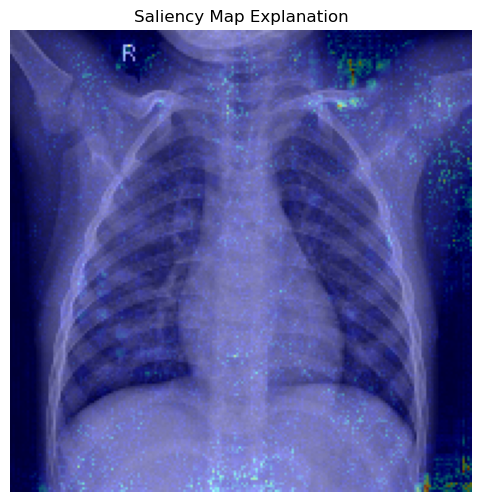

In [71]:
original = cv2.imread(img_path)
original = cv2.resize(original, (192,192))

saliency = cv2.resize(saliency, (192,192))
saliency = np.uint8(255 * saliency)
saliency = cv2.applyColorMap(saliency, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(original, 0.6, saliency, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Saliency Map Explanation")
plt.show()